In [22]:
# import the case 2 data
import pandas as pd

DATA_LOC = "../data/HR_data.csv"
ID_STR = "Individual"

raw_data = pd.read_csv(DATA_LOC)

# Split data into features and target; features would be the columns with 'HR_TD_', 'TEMP_TD', and 'EDA_TD' (about 48 columns);
# The rest goes to target variable Y
X = raw_data.filter(regex='HR_TD_|TEMP_TD|EDA_TD_|Individual')
Y = raw_data.drop(columns=X.columns)

X.head()

,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,EDA_TD_T_Kurtosis,EDA_TD_T_Skew,EDA_TD_T_Slope_min,EDA_TD_T_Slope_max,EDA_TD_T_Slope_mean,EDA_TD_T_Slope,EDA_TD_P_Peaks,EDA_TD_P_RT,EDA_TD_P_ReT,Individual
0,78.663878,76.70,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.7300,0.9775,...,1.345997,-1.379434,-0.000144,0.000138,0.000010,1.036040e-05,11,2.522727,2.075000,1
1,76.540732,76.61,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.3600,0.1900,...,0.887010,0.854067,-0.000146,0.000165,0.000009,7.714503e-06,15,2.214286,2.192308,1
2,78.173563,77.92,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.6300,0.3575,...,0.205817,0.480581,-0.000112,0.000132,0.000002,1.799914e-06,10,1.972222,2.111111,1
3,83.073688,83.88,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.4650,0.6500,...,2.488339,1.246665,-0.000455,0.000481,-0.000001,-1.355151e-07,12,1.886364,1.805556,1
4,72.281250,72.91,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.3725,0.3375,...,1.196508,1.592099,-0.000420,0.000334,0.000014,1.267198e-05,20,1.812500,1.926471,1


In [25]:
raw_data[ID_STR].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26])

In [43]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

# We want to scale the features (X) but grouped by the individuals (ID column).
# This is because we want to preserve the relative differences between the features for each individual, while also ensuring that the features are on a similar scale across all individuals.
# The target are emotional states, so if we globally did it, a person with higher baseline heart rate would have higher values for all features, which might not be ideal.
scaler = StandardScaler()

X_scaled_individual = X.copy().groupby(raw_data[ID_STR]).transform(lambda x: scaler.fit_transform(x.to_frame())[:, 0] if x.ndim == 1 else scaler.fit_transform(x))
X_scaled_individual = X_scaled_individual.fillna(0)

In [45]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Variables
k_clusters = 3  # How many latent states do we want? I am just starting with 3 for now. We can experiment with different values of k later on.
k_components = 3

# --------------------------------------------------------- ---
# K-MEANS CLUSTERING (FIRST PART OF THIS TASK I AM GOING TO DO)
# -------------------------------------------------------------
kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled_individual)

kmeans_silhouette = silhouette_score(X_scaled_individual, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_silhouette:.3f}")
# ---------------------------------------------------------
# GAUSSIAN MIXTURE MODELS
# ---------------------------------------------------------
gmm = GaussianMixture(n_components=k_components, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled_individual)

# GMM also allows us to see the probability of each point belonging to a cluster
gmm_probabilities = gmm.predict_proba(X_scaled_individual)

gmm_silhouette = silhouette_score(X_scaled_individual, gmm_labels)
print(f"GMM Silhouette Score: {gmm_silhouette:.3f}")

# ---------------------------------------------------------
# MAPPING CLUSTERS TO EMOTIONS (The core of the case)
# ---------------------------------------------------------
Y_analysis = Y.copy()
Y_analysis['KMeans_Cluster'] = kmeans_labels
Y_analysis['GMM_Cluster'] = gmm_labels

emotion_cols = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']

# Calculate the mean value of each emotion for each GMM cluster. This will show us the "emotional profile" of each latent state
cluster_profiles = Y_analysis.groupby('GMM_Cluster')[emotion_cols].mean()
print("\n--- Mean Emotional Scores per GMM Cluster ---")
print(cluster_profiles)

K-Means Silhouette Score: 0.070
GMM Silhouette Score: 0.102

--- Mean Emotional Scores per GMM Cluster ---
             Frustrated     upset  hostile     alert   ashamed  inspired  \
GMM_Cluster                                                                
0              1.469388  1.183673    1.000  1.959184  1.265306  2.081633   
1              1.925714  1.320000    1.040  2.177143  1.160000  2.121387   
2              2.522727  1.488636    1.125  2.352273  1.318182  2.363636   

              nervous  attentive    afraid    active  determined  
GMM_Cluster                                                       
0            1.408163   2.714286  1.061224  2.326531    2.775510  
1            1.342857   2.747126  1.051724  2.505747    2.930636  
2            1.443182   2.897727  1.045455  2.772727    2.954545  


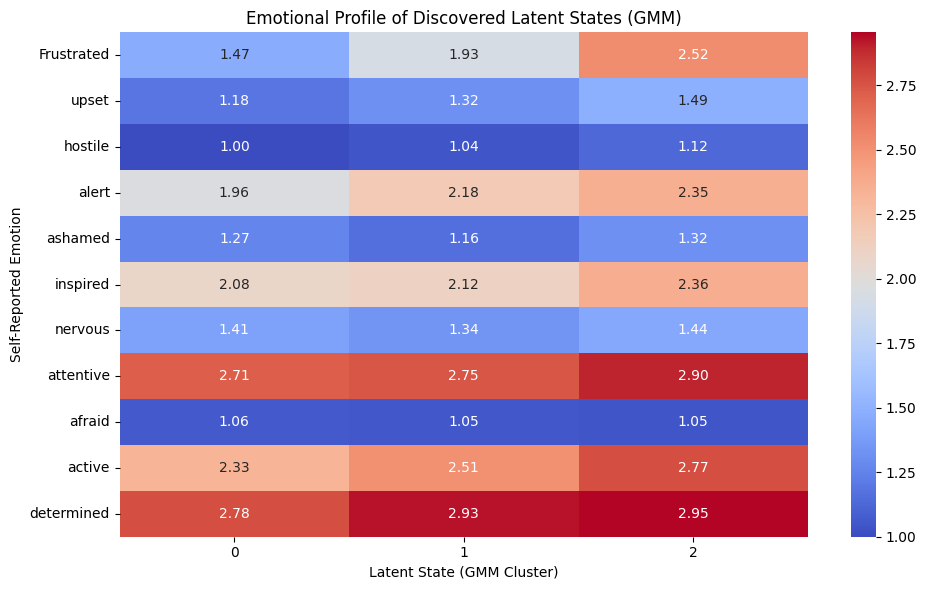

In [46]:
# Heatmap of the emotional profiles to easily interpret the latent states
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles.T, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Emotional Profile of Discovered Latent States (GMM)')
plt.xlabel('Latent State (GMM Cluster)')
plt.ylabel('Self-Reported Emotion')
plt.tight_layout()
plt.show()